# Focal Spot Comparison

This notebook compares the focal spot intensity profiles of an optimized diffractive cascade against a conventional Fresnel zone plate. It loads simulation results from a specific optimization run, reconstructs the simulation grid, and plots the 1D intensity cross-sections at focus for both designs to illustrate the improvement in peak intensity and spot shape achieved by the cascade.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

from src.simparams import SimParams

In [3]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

In [4]:
fzp_color = (np.float64(0.4), np.float64(0.6509803921568628), np.float64(0.11764705882352941), np.float64(1.0))

In [5]:
path = repo_root / "paper_data"

params = np.load(path / "fig1_N_sweeps_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "fig1_N_sweeps_sweep_arrays.npy", allow_pickle=True).item()
results_np = np.load(path / "fig1_N_sweeps_results_run_0.npz", allow_pickle=True)

materials = sweep_arrs["materials"]
Nelems = sweep_arrs["Nelems"]
material_idx = list(materials).index("au")
Nelem_idx = int(np.where(Nelems == 10)[0][0])

results = {
    "opt_intensity": np.asarray(results_np["opt_intensities"][material_idx, Nelem_idx], dtype=np.float64),
    "fzp_intensity": np.asarray(results_np["fzp_intensities"][material_idx, Nelem_idx], dtype=np.float64),
    "opt_efficiency": float(results_np["opt_efficiencies"][material_idx, Nelem_idx]),
    "fzp_efficiency": float(results_np["fzp_efficiencies"][material_idx, Nelem_idx]),
}

In [8]:
opt_intensity = results['opt_intensity']
fzp_intensity = results["fzp_intensity"]

In [9]:
Nx = params["Nx"]
sim_params = SimParams(
    Ny = 1, 
    Nx = Nx,
    dx = params["dx"],
    device='cpu',
    dtype = torch.complex128,
    lams = [], 
    weights = []
)
x = sim_params.x

In [10]:
opt_efficiency = results["opt_efficiency"]
opt_efficiency

0.38232025504112244

In [11]:
fzp_efficiency = results["fzp_efficiency"]
fzp_efficiency

0.02716062217950821

In [12]:
x_upsample = np.linspace(x.min(), x.max(), int(10*Nx - 1))

opt_cs = scipy.interpolate.CubicSpline(x, opt_intensity)
fzp_cs = scipy.interpolate.CubicSpline(x, fzp_intensity)

opt_intensity_upsample = opt_cs(x_upsample)
fzp_intensity_upsample = fzp_cs(x_upsample)

In [13]:
opt_intensity_upsample.max() / fzp_intensity_upsample.max()

np.float64(2.7316721471719183)

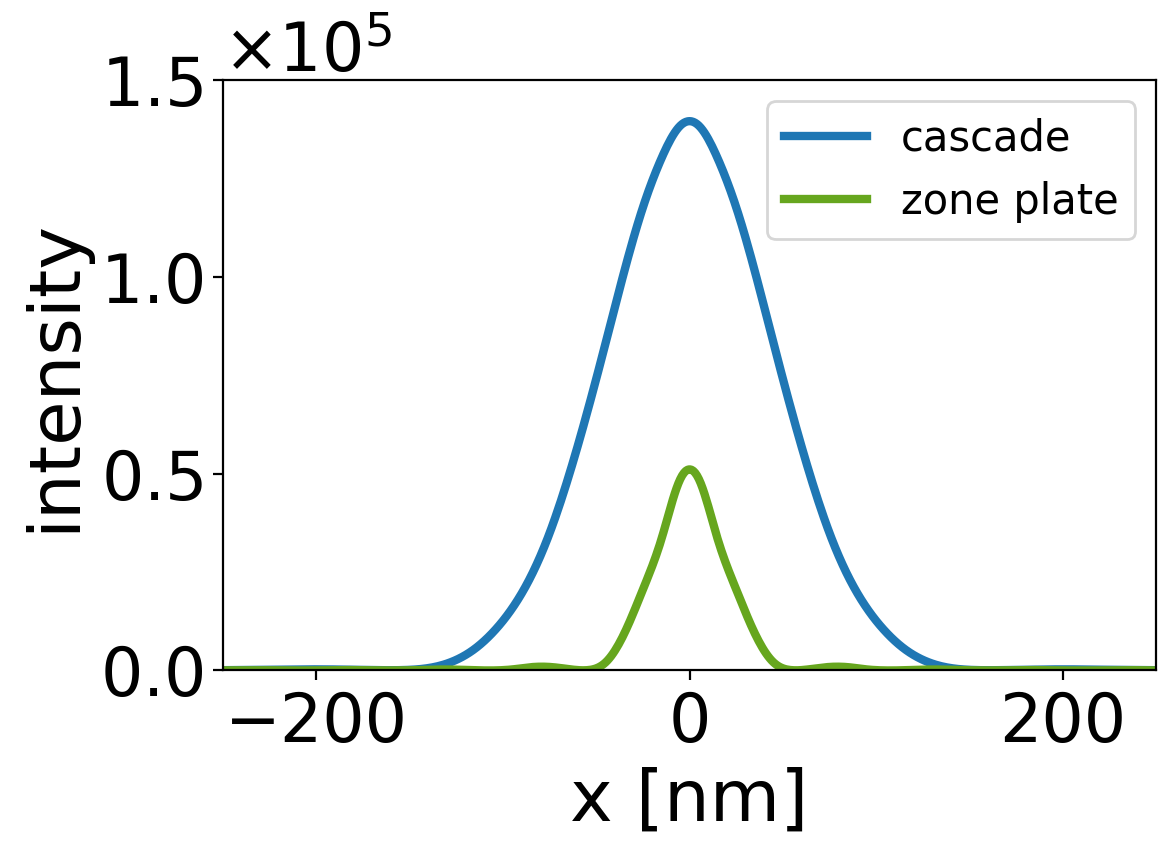

In [14]:
plt.plot(x_upsample*1e9, opt_intensity_upsample, linewidth=3, label='cascade')
plt.plot(x_upsample*1e9, fzp_intensity_upsample, linewidth=3, label='zone plate', color=fzp_color)

plt.xlabel('x [nm]', fontsize=26)
plt.ylabel('intensity', fontsize=26)
plt.xlim(-250, 250)
plt.ylim(0, 1.5e5)
plt.legend(loc='upper right', fontsize=15)
plt.tick_params(labelsize=24)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True) 
plt.tight_layout()
plt.show()